In [50]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import nltk
import nltk
nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import string

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [51]:
import kagglehub

path = kagglehub.dataset_download(
   "uciml/sms-spam-collection-dataset"
)

# Load CSV
print("Dataset path:",path)
print(os.listdir(path))

Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.
Dataset path: /kaggle/input/sms-spam-collection-dataset
['spam.csv']


In [52]:
csv_file = os.path.join(path, "spam.csv")

df = pd.read_csv(csv_file, encoding="latin-1")

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [54]:
df.shape

(5572, 5)

In [55]:
df = df[['v1','v2']]

df.columns = ['label','message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [56]:
df['label'] = df['label'].map({
    'ham':0,
    'spam':1
})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [57]:
stop_words = set(stopwords.words('english'))

In [58]:
def preprocess(text):

    text = text.lower()

    text = text.translate(str.maketrans('', '', string.punctuation))

    words = word_tokenize(text)

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [59]:
import nltk
nltk.download('punkt_tab')

df['clean_message'] = df['message'].apply(preprocess)

df.head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,label,message,clean_message
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,0,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


In [60]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['clean_message'])

y = df['label']

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [62]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [63]:
y_pred = model.predict(X_test)

In [64]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.9659192825112107


In [65]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.75      0.85       150

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115



In [66]:
print("Total Emails :", len(df))

Total Emails : 5572


In [67]:
spam = df[df['label']==1]

print("Spam Emails :", len(spam))

Spam Emails : 747


In [68]:
ham = df[df['label']==0]

print("Non-Spam Emails :", len(ham))

Non-Spam Emails : 4825


In [69]:
spam_percentage = (len(spam)/len(df))*100

print("Spam Percentage :", round(spam_percentage,2),"%")

Spam Percentage : 13.41 %


In [70]:
ham_percentage = (len(ham)/len(df))*100

print("Non-Spam Percentage :", round(ham_percentage,2),"%")

Non-Spam Percentage : 86.59 %


In [71]:
print("----------- Spam Analysis Report -----------")
print("Total Emails        :", len(df))
print("Spam Emails         :", len(spam))
print("Non-Spam Emails     :", len(ham))
print("Spam Percentage     :", round(spam_percentage,2),"%")
print("Non-Spam Percentage :", round(ham_percentage,2),"%")
print("Model Accuracy      :", round(accuracy*100,2),"%")

----------- Spam Analysis Report -----------
Total Emails        : 5572
Spam Emails         : 747
Non-Spam Emails     : 4825
Spam Percentage     : 13.41 %
Non-Spam Percentage : 86.59 %
Model Accuracy      : 96.59 %


In [72]:
email = ["Congratulations! You have won a free iPhone. Click here to claim now."]

In [73]:
clean_email = [preprocess(email[0])]

email_vector = vectorizer.transform(clean_email)

prediction = model.predict(email_vector)

if prediction[0] == 1:
    print("Spam Email")
else:
    print("Not Spam Email")

Spam Email


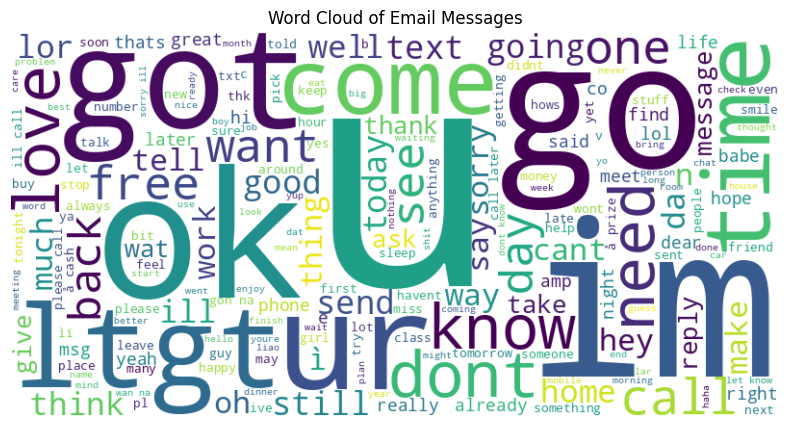

In [74]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
text = " ".join(df['clean_message'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Email Messages")
plt.show()